# BER Verification

Reports the BER and the receive-side SNR / Eb/N0 at the nominal SNR, then sweeps SNR to produce a BER vs Eb/N0 curve.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from tx_setup import build_test_setup
from rfmodel.core.units import dbm_to_w, w_to_dbm


In [16]:
setup = build_test_setup(input_pwr_dbm=-25.0, enable_ofdm_weighting=True)

pipe                = setup.pipe
qam                 = setup.qam
ofdm                = setup.ofdm
sig_bits            = setup.sig_bits
sig_ofdm_normalized = setup.sig_ofdm_normalized
bits_per_symbol     = setup.bits_per_symbol

## BER at nominal SNR

In [17]:
sig_ber_out, ber_taps = pipe.run(sig_ofdm_normalized, taps=['PathLoss', 'AWGN'])

rx_syms      = ofdm.demodulate(sig_ber_out).x
rx_syms_norm = rx_syms / np.sqrt(np.mean(np.abs(rx_syms) ** 2))

Bits_rx = qam.demap(rx_syms_norm)

if len(Bits_rx) != len(sig_bits.x):
    print('ERROR: length mismatch — cannot compute BER')
else:
    errors      = sig_bits.x ^ Bits_rx
    error_count = int(np.sum(errors))
    ber_sim     = error_count / len(sig_bits.x)

    noise   = ber_taps['AWGN'].x - ber_taps['PathLoss'].x
    sig_pwr = np.mean(np.abs(ber_taps['PathLoss'].x) ** 2)
    nse_pwr = np.mean(np.abs(noise) ** 2)
    snr_lin  = sig_pwr / nse_pwr
    snr_db   = 10 * np.log10(snr_lin)
    ebn0_lin = snr_lin / bits_per_symbol
    ebn0_db  = 10 * np.log10(ebn0_lin)

    print(f'Errors:       {error_count} / {len(sig_bits.x)} bits')
    print(f'BER (sim):    {ber_sim:.4e}  ({ber_sim*100:.3f} %)')
    print(f'SNR (rx):     {snr_db:.2f} dB')
    print(f'Eb/N0:        {ebn0_db:.2f} dB')

Errors:       0 / 19968 bits
BER (sim):    0.0000e+00  (0.000 %)
SNR (rx):     47.68 dB
Eb/N0:        39.90 dB


## BER vs Eb/N0 sweep

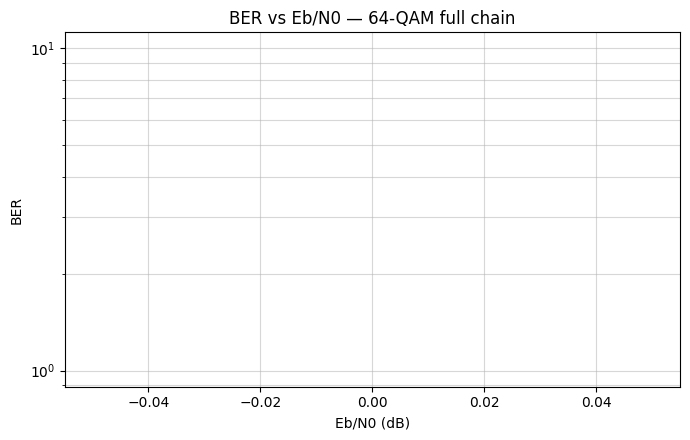

In [18]:
# Sweep the AWGN-block SNR and trace BER vs Eb/N0.

awgn_block = pipe.get('AWGN')
snr_saved  = awgn_block.params.snr_db

snr_sweep_db  = np.arange(0, 100, 2)
ebn0_sweep_db = snr_sweep_db - 10 * np.log10(bits_per_symbol)

ebn0_list = []
ber_list  = []

for snr_db, ebn0_db in zip(snr_sweep_db, ebn0_sweep_db):
    awgn_block.params.snr_db = snr_db
    sig_out, _ = pipe.run(sig_ofdm_normalized)

    rx_norm = ofdm.demodulate(sig_out).x
    rx_norm = rx_norm / np.sqrt(np.mean(np.abs(rx_norm) ** 2))
    n_err   = int(np.sum(sig_bits.x ^ qam.demap(rx_norm)))

    if n_err > 0:
        ebn0_list.append(ebn0_db)
        ber_list.append(n_err / len(sig_bits.x))

awgn_block.params.snr_db = snr_saved

plt.figure(figsize=(7, 4.5))
plt.semilogy(ebn0_list, ber_list, 'o-')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('BER')
plt.title('BER vs Eb/N0 — 64-QAM full chain')
if ber_list:
    plt.ylim(ber_list[-1], 1)
plt.grid(True, which='both', alpha=0.5)
plt.tight_layout()
plt.show()

## Sensitivity sweep — chip input

Sweeps TX input power downward and reports BER vs the power **at the LNA input** (chip-input plane, sampled at the `AWGN` tap which sits just before the LNA). The channel AWGN block is bypassed (`snr_db = 200`) so the only noise sources are the LNA + RX-mixer NF — i.e. this is true chip sensitivity, not a system sensitivity that includes channel noise.

Sensitivity is the **lowest chip-input power** that still meets the target BER.

## Bench-Test Sensitivity — Thermal Noise Only (T = 290 K)

Simulates a signal generator connected directly to the LNA input via a coaxial cable.
The TX chain (mixer, PA, path loss) is **bypassed**; noise sources are:

1. **kTB from the cable / source impedance** — AWGN noise power is fixed at $kTB$ where $B = f_s$ is the complex-baseband noise bandwidth.
2. **RX chain NF** — LNA and RX mixer still add their own thermal noise.

Because $kTB$ is a *fixed* power floor the AWGN SNR must be recomputed at every sweep point so that the noise power stays constant at $kTB$ regardless of signal level:

$$\mathrm{SNR}(P_\mathrm{in}) = \frac{P_\mathrm{in}}{kTB} \quad\Longrightarrow\quad \mathrm{SNR_{dB}} = P_\mathrm{in,dBm} - kTB_\mathrm{dBm}$$

kTB @ 290 K, B = 20 MHz : -100.96 dBm
Sensitivity (BER <= 1e-05): -74.00 dBm @ chip input


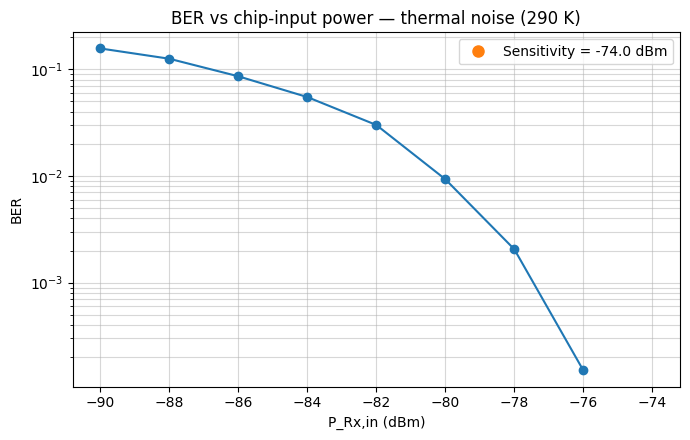

In [19]:
# Thermal noise floor (printed for reference)
kTB_W   = 1.380649e-23 * 290.0 * setup.fs_hz
kTB_dBm = 10 * np.log10(kTB_W / 1e-3)
print(f"kTB @ 290 K, B = {setup.fs_hz*1e-6:.0f} MHz : {kTB_dBm:.2f} dBm")

# Bypass TX chain — inject directly at the LNA input
pipe.enable('mixer_and_pll_TX', False)
pipe.enable('PA_TX',            False)
pipe.enable('PathLoss',         False)

# Switch AWGN to thermal mode: noise power fixed at kTB regardless of signal level
awgn_block = pipe.get('AWGN')
snr_saved         = awgn_block.params.snr_db
thermal_saved     = awgn_block.params.thermal_noise

awgn_block.params.thermal_noise = True   # kTB at 290 K, fs_hz from Signal
awgn_block.params.temp_k        = 290.0

target_ber     = 1e-5
p_in_sweep_dbm = np.arange(-90.0, -20.0, 2.0)

sig_ofdm  = setup.sig_ofdm
current_w = np.mean(np.abs(sig_ofdm.x) ** 2)

p_chip_dbm = np.empty_like(p_in_sweep_dbm)
ber_sweep  = np.empty_like(p_in_sweep_dbm)

for i, pin in enumerate(p_in_sweep_dbm):
    scale      = np.sqrt(dbm_to_w(pin) / current_w)
    s_in       = sig_ofdm.copy_with(x=sig_ofdm.x * scale)
    sig_out, _ = pipe.run(s_in)

    rx    = ofdm.demodulate(sig_out).x
    rx    = rx / np.sqrt(np.mean(np.abs(rx) ** 2))
    n_err = int(np.sum(sig_bits.x ^ qam.demap(rx)))

    p_chip_dbm[i] = pin   # TX chain bypassed → pin is the chip-input power
    ber_sweep[i]  = n_err / len(sig_bits.x)

# Restore pipeline
pipe.enable('mixer_and_pll_TX', True)
pipe.enable('PA_TX',            True)
pipe.enable('PathLoss',         True)
awgn_block.params.thermal_noise = thermal_saved
awgn_block.params.snr_db        = snr_saved

# Sensitivity point
ok       = ber_sweep <= target_ber
sens_dbm = float(p_chip_dbm[ok].min()) if ok.any() else None
if sens_dbm is not None:
    print(f'Sensitivity (BER <= {target_ber:.0e}): {sens_dbm:.2f} dBm @ chip input')
else:
    print(f'Target BER {target_ber:.0e} not reached — extend sweep to higher P_in')

mask = ber_sweep > 0
plt.figure(figsize=(7, 4.5))
plt.semilogy(p_chip_dbm[mask], ber_sweep[mask], 'o-')
if sens_dbm is not None:
    idx = np.where(ok)[0][0]
    plt.semilogy(p_chip_dbm[idx], ber_sweep[idx], 'o',
                 markersize=8, label=f'Sensitivity = {sens_dbm:.1f} dBm')
    plt.legend()
plt.xlabel('P_Rx,in (dBm)')
plt.ylabel('BER')
plt.title('BER vs chip-input power — thermal noise (290 K)')
plt.grid(True, which='both', alpha=0.5)
plt.tight_layout()
plt.show()